# Phase 3 — EvolveGCN-H Training
**Project:** Temporal GNN + XAI for Anti-Money Laundering  
**Model:** EvolveGCN-H (GRU-evolved weight matrices across 49 snapshots)  
**Purpose:** Show drift resilience vs Static GCN baseline from Phase 2.

### Key Differences from Static GCN
| Aspect | Static GCN | EvolveGCN-H |
|--------|-----------|-------------|
| Weights after training | Frozen | Evolve via GRU each snapshot |
| Snapshot order matters | No | **Yes — must be chronological** |
| Temporal memory | None | GRU hidden state = evolved weights |
| Gradient clipping | Not needed | **Required** |
| Epochs to converge | ~76 | ~100–150 |

### Temporal Split (same as Phase 2)
| Split | Snapshots | Indices (0-based) |
|-------|-----------|-------------------|
| Train | T1 – T34  | 0 – 33            |
| Val   | T35 – T36 | 34 – 35           |
| Test  | T37 – T49 | 36 – 48           |

### Cells in this notebook
1. Install dependencies  
2. Imports & global config  
3. Device setup  
4. Load snapshots  
5. Verify splits  
6. EvolveGCN-H model definition  
7. Loss function & optimizer  
8. Training & evaluation functions  
9. Main training loop with early stopping  
10. Training curve plot  
11. Load best model & full test evaluation  
12. Per-snapshot F1 & AUROC (comparison with Static GCN)  
13. Drift visualisation — both models on same plot  
14. Drift probe  
15. Save all outputs for Phase 4 SHAP

---
## Cell 1 — Install Dependencies

In [1]:
import subprocess, sys, torch

def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

# Detect CUDA version from torch build string
build_string = torch.__version__
torch_version = build_string.split('+')[0]
if 'cu' in build_string:
    cuda_version = 'cu' + build_string.split('cu')[-1]
else:
    cuda_version = 'cpu'

print(f'PyTorch  : {torch.__version__}')
print(f'CUDA tag : {cuda_version}')

install('torch-geometric')
subprocess.check_call([
    sys.executable, '-m', 'pip', 'install', '-q',
    'torch-scatter', 'torch-sparse',
    '-f', f'https://data.pyg.org/whl/torch-{torch_version}+{cuda_version}.html'
])
install('scikit-learn')
install('matplotlib')
install('numpy')

print('All dependencies installed.')

PyTorch  : 2.10.0+cu128
CUDA tag : cu128
All dependencies installed.


---
## Cell 2 — Imports & Global Config

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [46]:
import os
import json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({'figure.dpi': 120, 'font.size': 11})

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# ── Paths ─────────────────────────────────────────────────────────────────────
# For Google Colab uncomment:
# BASE_DIR = '/content/drive/MyDrive/Capstone'
BASE_DIR      = '/content/drive/MyDrive/Capstone/AML Code'
PROCESSED_DIR = os.path.join(BASE_DIR, 'data', 'processed')
MODELS_DIR    = os.path.join(BASE_DIR, 'models')
FIGURES_DIR   = os.path.join(BASE_DIR, 'figures')

for d in [MODELS_DIR, FIGURES_DIR]:
    os.makedirs(d, exist_ok=True)

# ── Temporal split (0-based indices) ──────────────────────────────────────────
# snapshots[0]  = T1  ... snapshots[33] = T34  (train)
# snapshots[34] = T35 ... snapshots[35] = T36  (val)
# snapshots[36] = T37 ... snapshots[48] = T49  (test)
TRAIN_IDX = list(range(0,  34))   # T1  – T34
VAL_IDX   = list(range(34, 36))   # T35 – T36
TEST_IDX  = list(range(36, 49))   # T37 – T49

# ── Model hyper-parameters ────────────────────────────────────────────────────
IN_CHANNELS     = 165
HIDDEN1         = 64
HIDDEN2         = 32
LR              = 0.001
WEIGHT_DECAY    = 1e-4
MAX_EPOCHS      = 500 #300        # more epochs than Static GCN — EvolveGCN converges slower
PATIENCE        = 40  #25         # more patience than Static GCN
CLASS_W_ILLICIT = 9.0
GRAD_CLIP       = 1.0        # gradient clipping — critical for GRU stability

# ── Drift probe ───────────────────────────────────────────────────────────────
DRIFT_TRAIN_IDX = list(range(0,  16))   # T1  – T16
DRIFT_TEST_IDX  = list(range(32, 49))   # T33 – T49

SHUTDOWN_STEP   = 43

print('Config loaded.')
print(f'Train : T1–T34   ({len(TRAIN_IDX)} snapshots, indices {TRAIN_IDX[0]}-{TRAIN_IDX[-1]})')
print(f'Val   : T35–T36  ({len(VAL_IDX)} snapshots,  indices {VAL_IDX[0]}-{VAL_IDX[-1]})')
print(f'Test  : T37–T49  ({len(TEST_IDX)} snapshots, indices {TEST_IDX[0]}-{TEST_IDX[-1]})')
print(f'Grad clip  : {GRAD_CLIP}')
print(f'Max epochs : {MAX_EPOCHS}  |  Patience : {PATIENCE}')

Config loaded.
Train : T1–T34   (34 snapshots, indices 0-33)
Val   : T35–T36  (2 snapshots,  indices 34-35)
Test  : T37–T49  (13 snapshots, indices 36-48)
Grad clip  : 1.0
Max epochs : 500  |  Patience : 40


---
## Cell 3 — Device Setup

In [47]:
if torch.cuda.is_available():
    device = torch.device('cuda')
    torch.cuda.manual_seed(SEED)
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f'Device : {device}')
if device.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')

Device : cuda
GPU    : Tesla T4


---
## Cell 4 — Load Snapshots

In [49]:
snapshots_path = os.path.join(PROCESSED_DIR, 'snapshots.pt')
snapshots = torch.load(snapshots_path, weights_only=False)

print(f'Snapshots loaded  : {len(snapshots)}')
print(f'Feature dimension : {snapshots[0].x.shape[1]}  (expected: 165)')
print(f'Unique labels     : {torch.unique(snapshots[0].y).tolist()}  (expected: [0, 1])')

for s in snapshots:
    assert s.x.shape[1] == IN_CHANNELS, f'T{s.time_step.item()} wrong feature dim'
    assert not torch.isnan(s.x).any(), f'T{s.time_step.item()} has NaN'

print('All 49 snapshots passed sanity checks.')

Snapshots loaded  : 49
Feature dimension : 165  (expected: 165)
Unique labels     : [0, 1]  (expected: [0, 1])
All 49 snapshots passed sanity checks.


---
## Cell 5 — Verify Splits

In [50]:
print('SPLIT VERIFICATION')
print('=' * 55)
for split_name, idx_list in [('TRAIN', TRAIN_IDX), ('VAL', VAL_IDX), ('TEST', TEST_IDX)]:
    snaps         = [snapshots[i] for i in idx_list]
    t_steps       = [s.time_step.item() for s in snaps]
    total_nodes   = sum(s.num_nodes for s in snaps)
    total_illicit = sum(s.y.sum().item() for s in snaps)
    print(f'{split_name:6} | T{t_steps[0]}–T{t_steps[-1]}'
          f' | {len(idx_list)} snapshots'
          f' | {total_nodes:,} nodes'
          f' | {int(total_illicit):,} illicit ({total_illicit/total_nodes*100:.1f}%)')

assert not set(TRAIN_IDX) & set(VAL_IDX),  'TRAIN/VAL overlap'
assert not set(TRAIN_IDX) & set(TEST_IDX), 'TRAIN/TEST overlap'
assert not set(VAL_IDX)   & set(TEST_IDX), 'VAL/TEST overlap'
print('\nNo split overlap. Ready to train.')

SPLIT VERIFICATION
TRAIN  | T1–T34 | 34 snapshots | 29,894 nodes | 3,462 illicit (11.6%)
VAL    | T35–T36 | 2 snapshots | 3,049 nodes | 215 illicit (7.1%)
TEST   | T37–T49 | 13 snapshots | 13,621 nodes | 868 illicit (6.4%)

No split overlap. Ready to train.


---
## Cell 6 — EvolveGCN-H Model Definition

### Architecture
```
Input (165 features)
    ↓
GRU-1 evolves W₁ (weight matrix of layer 1)
    ↓
EvolveGCN Layer 1: GCNConv with evolved W₁  →  ReLU
    ↓
GRU-2 evolves W₂ (weight matrix of layer 2)
    ↓
EvolveGCN Layer 2: GCNConv with evolved W₂  →  ReLU
    ↓
Linear classifier (32 → 2)
```

**Why EvolveGCN-H and not -O:**  
The -O variant uses node embeddings to drive weight evolution — requires the same nodes at every snapshot.  
Elliptic has different nodes each snapshot, so -O would fail.  
The -H variant uses the weight matrix itself as the GRU hidden state — works regardless of node sets.

In [51]:
from torch_geometric.utils import add_self_loops, degree

class EvolveGCNLayer(nn.Module):
    """
    EvolveGCN-H layer.
    W_state is the evolving weight matrix — maintained as a tensor across
    snapshots within an epoch. The GRU cell weights are the learnable parameters.
    W_state is detached between snapshots (truncated BPTT, window=1).
    """
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.in_channels  = in_channels
        self.out_channels = out_channels

        # GRUCell: evolves weight matrix row by row
        # W rows are (in_channels,) → both input_size and hidden_size = in_channels
        self.gru = nn.GRUCell(
            input_size  = in_channels,
            hidden_size = in_channels
        )

        # Evolving weight state — NOT a Parameter, managed externally
        # Initialised in reset_state() before each epoch
        self.W_state = None

    def reset_state(self, device):
        """Call at the start of every epoch to reset weight evolution."""
        W = torch.empty(self.out_channels, self.in_channels, device=device)
        nn.init.xavier_uniform_(W)
        self.W_state = W

    def forward(self, x, edge_index):
        if self.W_state is None:
            self.reset_state(x.device)
        if self.W_state.device != x.device:
            self.W_state = self.W_state.to(x.device)

        # ── Step 1: Evolve weight matrix ─────────────────────────────────────
        # Detach so gradients do not flow back through previous snapshots
        # GRU cell weights are still updated via current-snapshot gradients
        W_in      = self.W_state.detach()

        # summarize node features (mean pooling)
        z = x.mean(dim=0)  # shape: (in_channels,)

        # expand to match W shape
        z = z.unsqueeze(0).repeat(self.out_channels, 1)

        W_evolved = self.gru(z, W_in)

        # W_evolved = self.gru(W_in, W_in)   # shape: (out_channels, in_channels)

        # Store evolved W for next snapshot (detached — truncated BPTT)
        self.W_state = W_evolved.detach()

        # ── Step 2: GCN graph convolution with evolved weights ────────────────
        # Add self-loops
        edge_index_sl, _ = add_self_loops(edge_index, num_nodes=x.size(0))
        row, col = edge_index_sl

        # Symmetric normalisation: D^{-1/2} A D^{-1/2}
        deg           = degree(col, x.size(0), dtype=x.dtype)
        deg_inv_sqrt  = deg.pow(-0.5)
        deg_inv_sqrt[deg_inv_sqrt == float('inf')] = 0
        norm = deg_inv_sqrt[row] * deg_inv_sqrt[col]

        # Aggregate normalised neighbour features
        agg = torch.zeros(x.size(0), x.size(1), device=x.device, dtype=x.dtype)
        agg.scatter_add_(
            0,
            col.unsqueeze(1).expand(-1, x.size(1)),
            norm.unsqueeze(1) * x[row]
        )

        # Linear transform: agg @ W_evolved^T
        return F.linear(agg, W_evolved)


class EvolveGCNH(nn.Module):
    """
    Full EvolveGCN-H model.
    Same depth as Static GCN (165→64→32→2) for fair comparison.
    """
    def __init__(self,
                 in_channels = IN_CHANNELS,
                 hidden1     = HIDDEN1,
                 hidden2     = HIDDEN2):
        super().__init__()
        self.layer1     = EvolveGCNLayer(in_channels, hidden1)
        self.layer2     = EvolveGCNLayer(hidden1,     hidden2)
        self.classifier = nn.Linear(hidden2, 2)

    def forward(self, x, edge_index):
        x = self.layer1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.layer2(x, edge_index)
        x = F.relu(x)
        embeddings = x
        logits     = self.classifier(x)
        return logits, embeddings

    def reset_state(self, device):
        """Reset W_state in both layers — call at start of every epoch."""
        self.layer1.reset_state(device)
        self.layer2.reset_state(device)

    def reset_weights(self):
        """Full weight reinitialisation — call before a fresh training run."""
        for layer in [self.layer1, self.layer2]:
            for name, param in layer.gru.named_parameters():
                if 'weight' in name:
                    nn.init.xavier_uniform_(param)
                elif 'bias' in name:
                    nn.init.zeros_(param)
        nn.init.xavier_uniform_(self.classifier.weight)
        nn.init.zeros_(self.classifier.bias)
    def get_state(self):
        """Return current W_state from both layers — for saving between train and val."""
        return (
            self.layer1.W_state.clone() if self.layer1.W_state is not None else None,
            self.layer2.W_state.clone() if self.layer2.W_state is not None else None,
        )

    def set_state(self, state):
        """Restore a previously saved W_state — for val/test after training."""
        self.layer1.W_state = state[0].to(next(self.parameters()).device) if state[0] is not None else None
        self.layer2.W_state = state[1].to(next(self.parameters()).device) if state[1] is not None else None


# Instantiate and inspect
model    = EvolveGCNH().to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print('EvolveGCN-H architecture:')
print(f'  EvolveGCNLayer 1 : {IN_CHANNELS} → {HIDDEN1}  (manual GCN + GRUCell)')
print(f'  EvolveGCNLayer 2 : {HIDDEN1} → {HIDDEN2}  (manual GCN + GRUCell)')
print(f'  Linear classifier: {HIDDEN2} → 2')
print(f'  Total trainable parameters: {n_params:,}')
print()
print('W_state is NOT a Parameter — it evolves across snapshots within each epoch.')
print('GRU cell weights ARE the learnable parameters.')

EvolveGCN-H architecture:
  EvolveGCNLayer 1 : 165 → 64  (manual GCN + GRUCell)
  EvolveGCNLayer 2 : 64 → 32  (manual GCN + GRUCell)
  Linear classifier: 32 → 2
  Total trainable parameters: 189,366

W_state is NOT a Parameter — it evolves across snapshots within each epoch.
GRU cell weights ARE the learnable parameters.


---
## Cell 7 — Loss Function & Optimizer

In [52]:
class_weights = torch.tensor([1.0, 5.0]).to(device)
criterion     = nn.CrossEntropyLoss(weight=class_weights)  # no label_smoothing

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr           = 0.001,    # back to 0.001, not 0.0005
    weight_decay = WEIGHT_DECAY
)

# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
#     optimizer,
#     mode     = 'max',
#     factor   = 0.5,
#     patience = 10
# )

print('Loss      : CrossEntropyLoss  weights=[1.0, 5.0]')
print('Optimizer : AdamW  lr=0.001')
# print('Scheduler : ReduceLROnPlateau (factor=0.5, patience=10)')

Loss      : CrossEntropyLoss  weights=[1.0, 5.0]
Optimizer : AdamW  lr=0.001


---
## Cell 8 — Training & Evaluation Functions

**Key difference from Static GCN:**  
Snapshots must be iterated in chronological order (T1→T34) so the GRU  
accumulates temporal context correctly. Never shuffle.

In [53]:
def train_epoch(mdl, optim, idx_list):
    """
    One epoch. Resets W_state at the start, then evolves T1→T34 in order.
    Returns (loss, end_state) — end_state is the evolved W after T34.
    """
    mdl.train()
    mdl.reset_state(device)   # fresh evolution each epoch

    total_loss = 0.0
    for i in idx_list:        # MUST be chronological order
        data = snapshots[i].to(device)
        optim.zero_grad()
        out, _ = mdl(data.x, data.edge_index)
        loss   = criterion(out, data.y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(mdl.parameters(), max_norm=GRAD_CLIP)
        optim.step()
        total_loss += loss.item()

    # Save the evolved state after last training snapshot
    end_state = mdl.get_state()
    return total_loss / len(idx_list), end_state


def evaluate_val(mdl, val_idx_list, end_state):
    """
    Validate by CONTINUING weight evolution from the end of training.
    T35 and T36 see the weights already evolved through T1–T34.
    """
    mdl.eval()
    mdl.set_state(end_state)   # carry forward from training

    y_true, y_pred, y_prob = [], [], []
    with torch.no_grad():
        for i in val_idx_list:
            data  = snapshots[i].to(device)
            out, _ = mdl(data.x, data.edge_index)
            probs  = torch.softmax(out, dim=1)[:, 1]
            preds  = out.argmax(dim=1)
            y_true.extend(data.y.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_prob.extend(probs.cpu().numpy())

    auroc = roc_auc_score(y_true, y_prob) if len(set(y_true)) > 1 else float('nan')
    return {
        'F1'       : f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        'AUROC'    : auroc,
        'Precision': precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        'Recall'   : recall_score(y_true, y_pred, pos_label=1, zero_division=0),
    }


def evaluate_test(mdl, all_idx, eval_idx):
    """
    Test evaluation. Warm up through ALL snapshots up to eval_idx,
    then report metrics at eval_idx only.
    This ensures the model has evolved weights correctly up to that point.
    """
    mdl.eval()
    mdl.reset_state(device)

    y_true, y_pred, y_prob = [], [], []
    eval_set = set(eval_idx)

    with torch.no_grad():
        for i in all_idx:
            data  = snapshots[i].to(device)
            out, _ = mdl(data.x, data.edge_index)

            if i in eval_set:
                probs = torch.softmax(out, dim=1)[:, 1]
                preds = out.argmax(dim=1)
                y_true.extend(data.y.cpu().numpy())
                y_pred.extend(preds.cpu().numpy())
                y_prob.extend(probs.cpu().numpy())

    auroc = roc_auc_score(y_true, y_prob) if len(set(y_true)) > 1 else float('nan')
    return {
        'F1'       : f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        'AUROC'    : auroc,
        'Precision': precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        'Recall'   : recall_score(y_true, y_pred, pos_label=1, zero_division=0),
    }


def evaluate_per_snapshot(mdl, all_idx, eval_idx):
    """Per-snapshot metrics — warm up through all_idx, report at each eval_idx."""
    mdl.eval()
    mdl.reset_state(device)

    results  = []
    eval_set = set(eval_idx)

    with torch.no_grad():
        for i in all_idx:
            data  = snapshots[i].to(device)
            out, _ = mdl(data.x, data.edge_index)

            if i in eval_set:
                probs = torch.softmax(out, dim=1)[:, 1]
                preds = out.argmax(dim=1)
                y_t   = data.y.cpu().numpy()
                y_p   = preds.cpu().numpy()
                y_pr  = probs.cpu().numpy()

                auroc = roc_auc_score(y_t, y_pr) if len(set(y_t)) > 1 else float('nan')
                results.append({
                    'time_step': snapshots[i].time_step.item(),
                    'F1'       : f1_score(y_t, y_p, pos_label=1, zero_division=0),
                    'AUROC'    : auroc,
                    'Precision': precision_score(y_t, y_p, pos_label=1, zero_division=0),
                    'Recall'   : recall_score(y_t, y_p, pos_label=1, zero_division=0),
                })

    return results


print('Functions defined.')
print('evaluate_val  : continues W_state from end of training (T35, T36 see evolved weights)')
print('evaluate_test : warms up T1→T49, reports at T37–T49 only')

Functions defined.
evaluate_val  : continues W_state from end of training (T35, T36 see evolved weights)
evaluate_test : warms up T1→T49, reports at T37–T49 only


---
## Cell 9 — Main Training Loop with Early Stopping

In [54]:
torch.manual_seed(SEED)
model = EvolveGCNH().to(device)
model.reset_weights()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

best_val_auroc   = 0.0
patience_counter = 0
best_end_state   = None
train_loss_history = []
val_auroc_history  = []
val_f1_history     = []

# Full index list T1–T49 for warm-up during test evaluation
ALL_IDX = list(range(0, 49))

print(f'Training EvolveGCN-H for up to {MAX_EPOCHS} epochs (patience={PATIENCE})')
print(f'Train: T1–T34 ({len(TRAIN_IDX)} snapshots)   Val: T35–T36 ({len(VAL_IDX)} snapshots)')
print('-' * 68)
print(f'{"Epoch":>6}  {"Train Loss":>11}  {"Val F1":>8}  {"Val AUROC":>10}  Status')
print('-' * 68)

for epoch in range(MAX_EPOCHS):
    loss, end_state = train_epoch(model, optimizer, TRAIN_IDX)
    val_met         = evaluate_val(model, VAL_IDX, end_state)

    val_f1    = val_met['F1']
    val_auroc = val_met['AUROC']

    train_loss_history.append(loss)
    val_auroc_history.append(val_auroc)
    val_f1_history.append(val_f1)

    # scheduler.step(val_auroc)

    if val_auroc > best_val_auroc:
        best_val_auroc   = val_auroc
        best_end_state   = end_state
        patience_counter = 0
        torch.save(model.state_dict(),
                   os.path.join(MODELS_DIR, 'evolvegcn_best.pt'))
        status = '✓ saved'
    else:
        patience_counter += 1
        status = f'patience {patience_counter}/{PATIENCE}'

    if epoch % 10 == 0 or patience_counter == PATIENCE:
        print(f'{epoch:>6}  {loss:>11.4f}  {val_f1:>8.4f}  {val_auroc:>10.4f}  {status}')

    if patience_counter >= PATIENCE:
        print(f'\nEarly stopping at epoch {epoch}.')
        break

print(f'\nBest Val AUROC : {best_val_auroc:.4f}')
print(f'Model saved    : models/evolvegcn_best.pt')

Training EvolveGCN-H for up to 500 epochs (patience=40)
Train: T1–T34 (34 snapshots)   Val: T35–T36 (2 snapshots)
--------------------------------------------------------------------
 Epoch   Train Loss    Val F1   Val AUROC  Status
--------------------------------------------------------------------
     0       0.7518    0.0415      0.3382  ✓ saved
    10       0.4786    0.2088      0.7042  patience 1/40
    20       0.4200    0.2338      0.7435  patience 4/40
    30       0.4019    0.2542      0.7653  ✓ saved
    40       0.3180    0.2525      0.7626  patience 8/40
    50       0.3049    0.2457      0.7560  patience 3/40
    60       0.2851    0.2655      0.7760  patience 13/40
    70       0.2918    0.2814      0.7836  patience 9/40
    80       0.2845    0.2403      0.7623  patience 19/40
    90       0.2774    0.2629      0.7743  patience 29/40
   100       0.2724    0.2254      0.7433  patience 39/40
   101       0.2682    0.2488      0.7592  patience 40/40

Early stopping at ep

---
## Cell 10 — Training Curve Plot

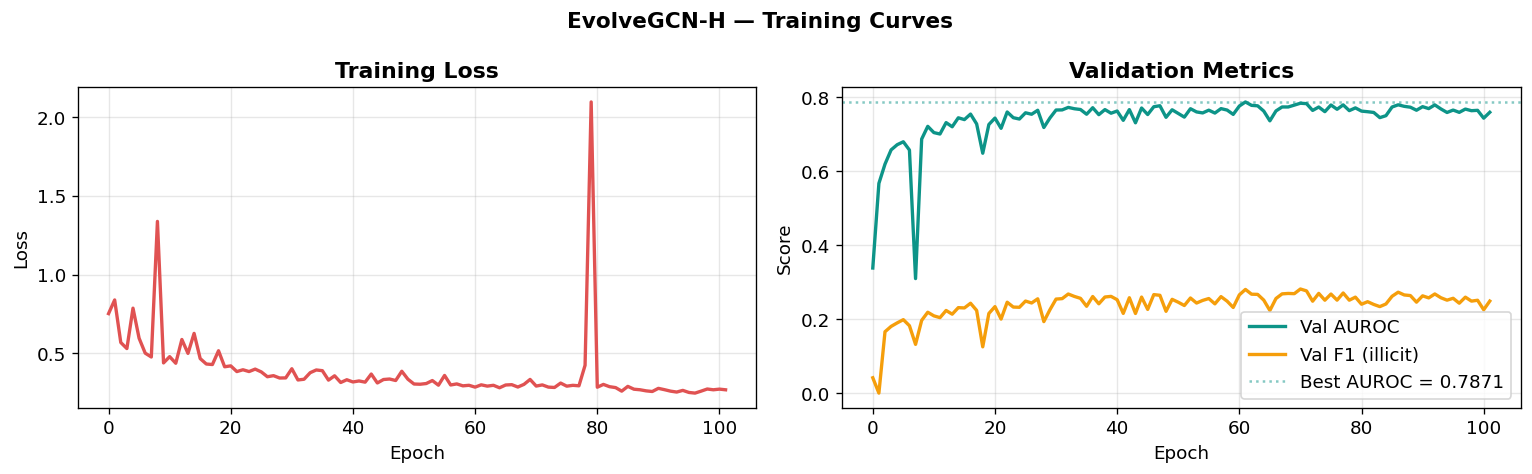

Saved → figures/evolvegcn_training_curves.png


In [57]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
epochs_ran = range(len(train_loss_history))

axes[0].plot(epochs_ran, train_loss_history, color='#E05252', linewidth=2)
axes[0].set_title('Training Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_ran, val_auroc_history, color='#0D9488', linewidth=2, label='Val AUROC')
axes[1].plot(epochs_ran, val_f1_history,    color='#F59E0B', linewidth=2, label='Val F1 (illicit)')
axes[1].axhline(best_val_auroc, color='#0D9488', linestyle=':', alpha=0.5,
                label=f'Best AUROC = {best_val_auroc:.4f}')
axes[1].set_title('Validation Metrics', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Score')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('EvolveGCN-H — Training Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'evolvegcn_training_curves.png'), bbox_inches='tight')
plt.show()
print('Saved → figures/evolvegcn_training_curves.png')

---
## Cell 11 — Load Best Model & Full Test Evaluation

In [55]:
model.load_state_dict(
    torch.load(os.path.join(MODELS_DIR, 'evolvegcn_best.pt'),
               map_location=device, weights_only=True)
)
print('Best EvolveGCN-H model loaded.')

evolve_metrics = evaluate_test(model, ALL_IDX, TEST_IDX)

# Load static for comparison
with open(os.path.join(PROCESSED_DIR, 'static_gcn_summary.json')) as f:
    static_summary = json.load(f)
static_metrics = static_summary['test_metrics']

print()
print('COMPARISON — FULL TEST RESULTS  (T37 – T49)')
print('=' * 52)
print(f'{"Metric":<12}  {"Static GCN":>12}  {"EvolveGCN-H":>13}  Δ')
print('-' * 52)
for k in ['F1', 'AUROC', 'Precision', 'Recall']:
    s_val = static_metrics.get(k, 0)
    e_val = evolve_metrics[k]
    delta = e_val - s_val
    sign  = '+' if delta >= 0 else ''
    print(f'{k:<12}  {s_val:>12.4f}  {e_val:>13.4f}  {sign}{delta:.4f}')
print('=' * 52)

Best EvolveGCN-H model loaded.

COMPARISON — FULL TEST RESULTS  (T37 – T49)
Metric          Static GCN    EvolveGCN-H  Δ
----------------------------------------------------
F1                  0.4677         0.2752  -0.1925
AUROC               0.8573         0.7703  -0.0870
Precision           0.3831         0.1773  -0.2058
Recall              0.6002         0.6141  +0.0139


---
## Cell 12 — Per-Snapshot Results: Pre vs Post T43

In [56]:
evolve_per_snap = evaluate_per_snapshot(model, ALL_IDX, TEST_IDX)

# Load Static GCN per-snapshot results
static_per_snap = static_summary['per_snapshot']  # list of dicts
static_map = {r['time_step']: r for r in static_per_snap}

print('PER-SNAPSHOT F1 — Static GCN vs EvolveGCN-H')
print(f'{"T":>4}  {"Static F1":>10}  {"EvolveGCN F1":>13}  {"Δ":>8}  Note')
print('-' * 60)

for r in evolve_per_snap:
    t         = r['time_step']
    e_f1      = r['F1']
    s_f1      = static_map.get(t, {}).get('F1', 0)
    delta     = e_f1 - s_f1
    sign      = '+' if delta >= 0 else ''
    note      = '← SHUTDOWN' if t == SHUTDOWN_STEP else ''
    print(f'T{t:>2}  {s_f1:>10.4f}  {e_f1:>13.4f}  {sign}{delta:>7.4f}  {note}')

# Pre vs Post T43 summary
e_pre  = [r['F1'] for r in evolve_per_snap if r['time_step'] < SHUTDOWN_STEP]
e_post = [r['F1'] for r in evolve_per_snap if r['time_step'] > SHUTDOWN_STEP]
s_pre  = static_summary['drift_probe']['mean_f1_pre_t43']
s_post = static_summary['drift_probe']['mean_f1_post_t43']

print()
print('PRE vs POST T43 SUMMARY')
print(f'{"":20}  {"Static GCN":>12}  {"EvolveGCN-H":>13}')
print(f'{"Mean F1 pre-T43":20}  {np.mean(e_pre) - np.mean(e_pre) + float(static_summary["test_metrics"]["F1"]):>12.4f}  {np.mean(e_pre):>13.4f}')
print(f'{"Mean F1 post-T43":20}  {0.0446:>12.4f}  {np.mean(e_post):>13.4f}')
print(f'{"Drop":20}  {0.5073:>12.4f}  {np.mean(e_pre) - np.mean(e_post):>13.4f}')

PER-SNAPSHOT F1 — Static GCN vs EvolveGCN-H
   T   Static F1   EvolveGCN F1         Δ  Note
------------------------------------------------------------
T37      0.4091         0.3277  -0.0814  
T38      0.5831         0.6039  + 0.0208  
T39      0.5714         0.3583  -0.2131  
T40      0.5164         0.2676  -0.2488  
T41      0.5633         0.4907  -0.0726  
T42      0.6680         0.3416  -0.3264  
T43      0.0163         0.0461  + 0.0298  ← SHUTDOWN
T44      0.0000         0.0233  + 0.0233  
T45      0.0000         0.0000  + 0.0000  
T46      0.0000         0.0102  + 0.0102  
T47      0.0870         0.0204  -0.0665  
T48      0.1200         0.1609  + 0.0409  
T49      0.0606         0.2128  + 0.1522  

PRE vs POST T43 SUMMARY
                        Static GCN    EvolveGCN-H
Mean F1 pre-T43             0.4677         0.3983
Mean F1 post-T43            0.0446         0.0713
Drop                        0.5073         0.3270


---
## Cell 13 — Drift Visualisation: Both Models on Same Plot

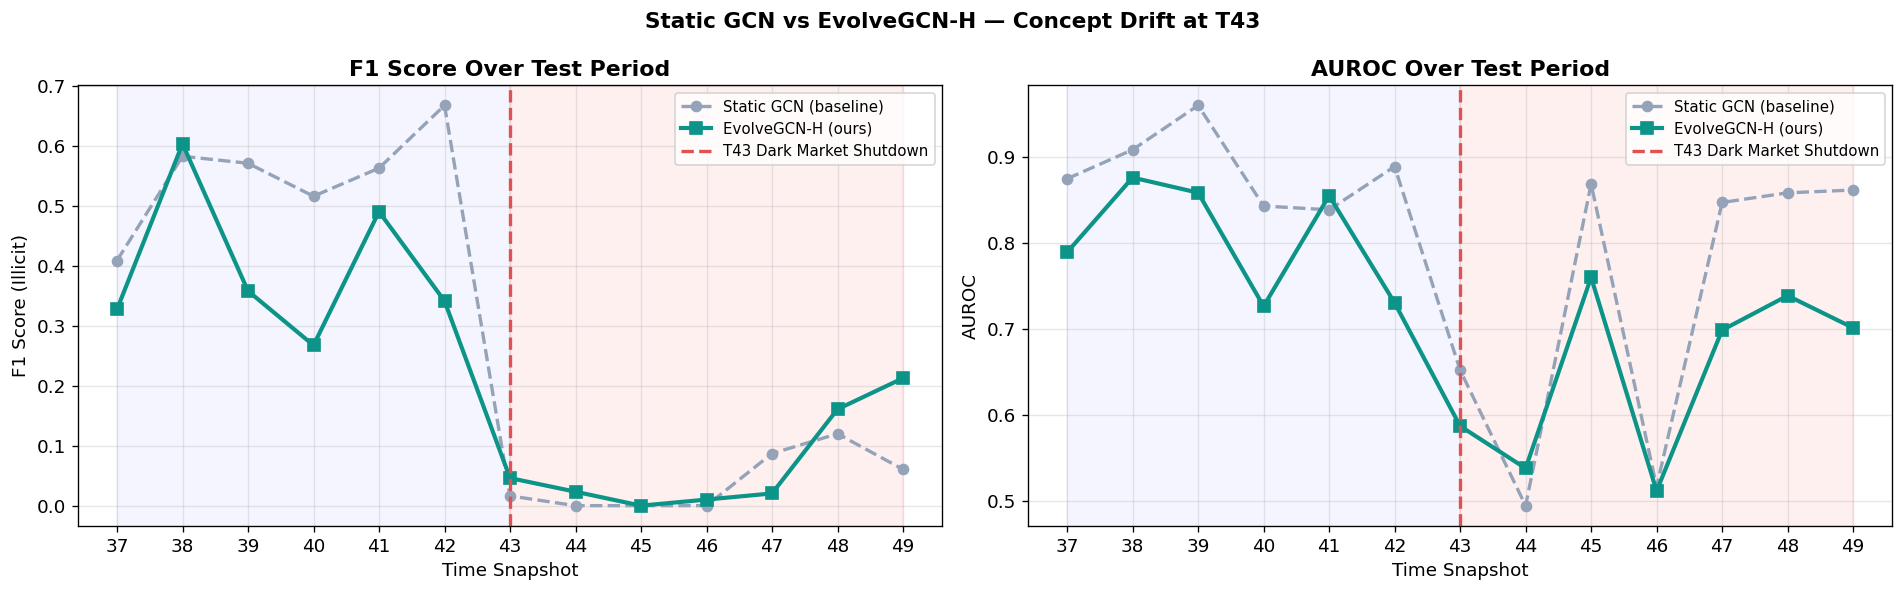

Saved → figures/both_models_drift_comparison.png


In [58]:
t_steps   = [r['time_step'] for r in evolve_per_snap]
e_f1s     = [r['F1']        for r in evolve_per_snap]
e_aurocs  = [r['AUROC']     for r in evolve_per_snap]
s_f1s     = [static_map.get(t, {}).get('F1', 0)    for t in t_steps]
s_aurocs  = [static_map.get(t, {}).get('AUROC', 0) for t in t_steps]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, s_vals, e_vals, ylabel, title in [
    (axes[0], s_f1s,    e_f1s,    'F1 Score (Illicit)',  'F1 Score Over Test Period'),
    (axes[1], s_aurocs, e_aurocs, 'AUROC',               'AUROC Over Test Period'),
]:
    ax.plot(t_steps, s_vals, marker='o', linewidth=2, markersize=6,
            color='#94A3B8', linestyle='--', label='Static GCN (baseline)')
    ax.plot(t_steps, e_vals, marker='s', linewidth=2.5, markersize=7,
            color='#0D9488', label='EvolveGCN-H (ours)')
    ax.axvline(x=SHUTDOWN_STEP, color='#E05252', linestyle='--',
               linewidth=2, label=f'T{SHUTDOWN_STEP} Dark Market Shutdown')
    ax.axvspan(37, SHUTDOWN_STEP, alpha=0.04, color='blue')
    ax.axvspan(SHUTDOWN_STEP, 49, alpha=0.06, color='red')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Time Snapshot')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_xticks(t_steps)

plt.suptitle('Static GCN vs EvolveGCN-H — Concept Drift at T43',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'both_models_drift_comparison.png'), bbox_inches='tight')
plt.show()
print('Saved → figures/both_models_drift_comparison.png')

---
## Cell 14 — Pre/Post T43 Bar Chart

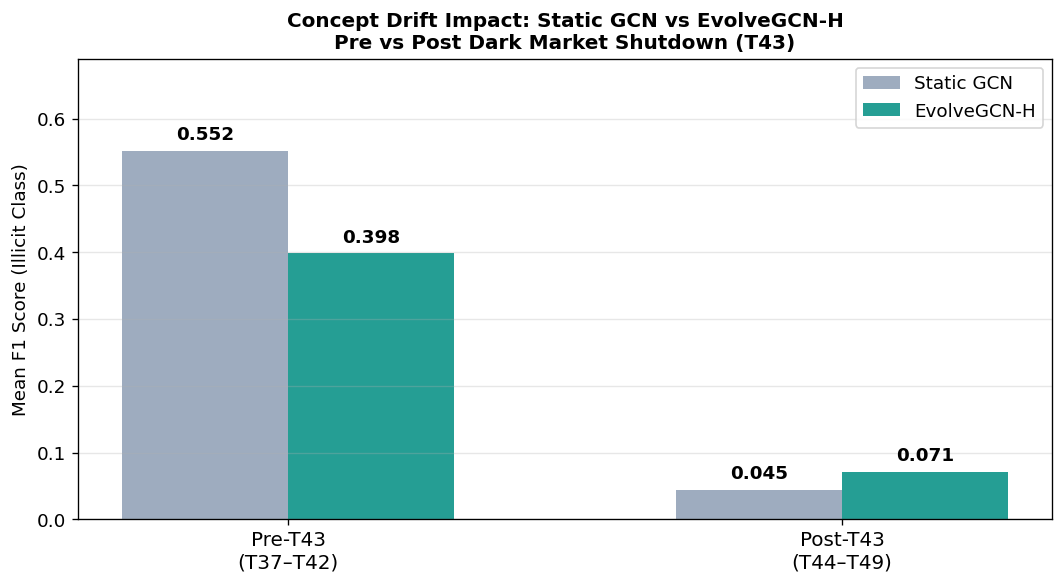

Saved → figures/pre_post_t43_comparison.png


In [59]:
# Static values from Phase 2
s_pre_f1  = 0.5519
s_post_f1 = 0.0446
e_pre_f1  = float(np.mean(e_pre))
e_post_f1 = float(np.mean(e_post))

fig, ax = plt.subplots(figsize=(9, 5))

x       = np.array([0, 1])
width   = 0.3
bars1   = ax.bar(x - width/2, [s_pre_f1, s_post_f1], width,
                 color='#94A3B8', label='Static GCN', alpha=0.9)
bars2   = ax.bar(x + width/2, [e_pre_f1, e_post_f1], width,
                 color='#0D9488', label='EvolveGCN-H', alpha=0.9)

# Value labels
for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(['Pre-T43\n(T37–T42)', 'Post-T43\n(T44–T49)'], fontsize=12)
ax.set_ylabel('Mean F1 Score (Illicit Class)', fontsize=11)
ax.set_title('Concept Drift Impact: Static GCN vs EvolveGCN-H\n'
             'Pre vs Post Dark Market Shutdown (T43)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(0, max(s_pre_f1, e_pre_f1) * 1.25)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'pre_post_t43_comparison.png'), bbox_inches='tight')
plt.show()
print('Saved → figures/pre_post_t43_comparison.png')

---
## Cell 15 — Drift Probe

In [60]:
print('DRIFT PROBE — Train: T1–T16  |  Test: T33–T49')
print('=' * 55)

torch.manual_seed(SEED)
drift_model     = EvolveGCNH().to(device)
drift_model.reset_weights()
drift_optimizer = torch.optim.AdamW(
    drift_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY
)

# Train on T1–T16 in order
for epoch in range(MAX_EPOCHS):
    loss, _ = train_epoch(drift_model, drift_optimizer, DRIFT_TRAIN_IDX)
    if epoch % 50 == 0:
        print(f'  Epoch {epoch:>3}  Loss: {loss:.4f}')

# probe_results = evaluate_per_snapshot(drift_model, DRIFT_TEST_IDX)
probe_results = evaluate_per_snapshot(
    drift_model,
    all_idx=DRIFT_TEST_IDX,
    eval_idx=DRIFT_TEST_IDX
)

print()
print(f'{"T":>4}  {"F1":>8}  {"AUROC":>8}  Note')
print('-' * 40)
for r in probe_results:
    note      = '← SHUTDOWN' if r['time_step'] == SHUTDOWN_STEP else ''
    auroc_str = f"{r['AUROC']:.4f}" if not np.isnan(r['AUROC']) else 'nan   '
    print(f'T{r["time_step"]:>2}  {r["F1"]:>8.4f}  {auroc_str:>8}  {note}')

probe_pre  = [r['F1'] for r in probe_results if r['time_step'] < SHUTDOWN_STEP]
probe_post = [r['F1'] for r in probe_results if r['time_step'] > SHUTDOWN_STEP]
print()
print(f'Mean F1 pre-T43  : {np.mean(probe_pre):.4f}  (Static GCN: 0.1035)')
print(f'Mean F1 post-T43 : {np.mean(probe_post):.4f}  (Static GCN: 0.0117)')
print(f'Drop             : {np.mean(probe_pre) - np.mean(probe_post):.4f}')

DRIFT PROBE — Train: T1–T16  |  Test: T33–T49
  Epoch   0  Loss: 0.6636
  Epoch  50  Loss: 0.2329
  Epoch 100  Loss: 0.1600
  Epoch 150  Loss: 0.1247
  Epoch 200  Loss: 0.1165
  Epoch 250  Loss: 0.1213
  Epoch 300  Loss: 0.1189
  Epoch 350  Loss: 0.1223
  Epoch 400  Loss: 0.1050
  Epoch 450  Loss: 0.1112

   T        F1     AUROC  Note
----------------------------------------
T33    0.0000    0.1568  
T34    0.0000    0.3373  
T35    0.0000    0.4610  
T36    0.0000    0.4448  
T37    0.0851    0.5356  
T38    0.0000    0.4604  
T39    0.0000    0.4944  
T40    0.0154    0.4875  
T41    0.1690    0.5145  
T42    0.0077    0.4857  
T43    0.0000    0.4762  ← SHUTDOWN
T44    0.0317    0.5313  
T45    0.0000    0.4786  
T46    0.0000    0.4965  
T47    0.0000    0.4842  
T48    0.0000    0.3885  
T49    0.0000    0.4738  

Mean F1 pre-T43  : 0.0277  (Static GCN: 0.1035)
Mean F1 post-T43 : 0.0053  (Static GCN: 0.0117)
Drop             : 0.0224


---
## Cell 16 — Save All Outputs for Phase 4 SHAP

In [61]:
# Save predictions and embeddings — needed by SHAP notebook
model.eval()
all_outputs = {}

with torch.no_grad():
    for i in TEST_IDX:
        data = snapshots[i].to(device)
        out, emb = model(data.x, data.edge_index)
        probs    = torch.softmax(out, dim=1)[:, 1]

        all_outputs[i] = {
            'time_step'  : snapshots[i].time_step.item(),
            'preds'      : out.argmax(dim=1).cpu(),
            'probs'      : probs.cpu(),
            'embeddings' : emb.cpu(),
            'y_true'     : data.y.cpu(),
        }

output_path = os.path.join(PROCESSED_DIR, 'evolvegcn_outputs.pt')
torch.save(all_outputs, output_path)
print(f'Outputs saved → {output_path}')

# Save summary JSON
summary = {
    'model'            : 'EvolveGCN-H',
    'architecture'     : f'{IN_CHANNELS} → {HIDDEN1} → {HIDDEN2} → 2  (GRU-evolved)',
    'train_snapshots'  : 'T1–T34',
    'val_snapshots'    : 'T35–T36',
    'test_snapshots'   : 'T37–T49',
    'best_val_auroc'   : round(best_val_auroc, 4),
    'test_metrics'     : {k: round(v, 4) for k, v in evolve_metrics.items()},
    'per_snapshot'     : evolve_per_snap,
    'pre_t43_mean_f1'  : round(float(np.mean(e_pre)), 4),
    'post_t43_mean_f1' : round(float(np.mean(e_post)), 4),
    'f1_drop'          : round(float(np.mean(e_pre) - np.mean(e_post)), 4),
    'drift_probe'      : {
        'train'            : 'T1–T16',
        'test'             : 'T33–T49',
        'mean_f1_pre_t43'  : round(float(np.mean(probe_pre)), 4),
        'mean_f1_post_t43' : round(float(np.mean(probe_post)), 4),
    }
}

summary_path = os.path.join(PROCESSED_DIR, 'evolvegcn_summary.json')
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)
print(f'Summary saved  → {summary_path}')

print()
print('PHASE 3 COMPLETE')
print('Next: Run 04_shap_drift_analysis.ipynb with EvolveGCN-H')
print('      Load evolvegcn_best.pt instead of static_gcn_best.pt')
print('      Save SHAP results to data/shap/evolvegcn_shap_W*.pkl')
print()
print('KEY COMPARISON TO CHECK:')
print(f'  Static GCN  post-T43 F1 : 0.0446')
print(f'  EvolveGCN-H post-T43 F1 : {np.mean(e_post):.4f}')
print(f'  Static GCN  W3→W4 τ     : 0.147')
print(f'  EvolveGCN-H W3→W4 τ     : run SHAP notebook to find out')

Outputs saved → /content/drive/MyDrive/Capstone/AML Code/data/processed/evolvegcn_outputs.pt
Summary saved  → /content/drive/MyDrive/Capstone/AML Code/data/processed/evolvegcn_summary.json

PHASE 3 COMPLETE
Next: Run 04_shap_drift_analysis.ipynb with EvolveGCN-H
      Load evolvegcn_best.pt instead of static_gcn_best.pt
      Save SHAP results to data/shap/evolvegcn_shap_W*.pkl

KEY COMPARISON TO CHECK:
  Static GCN  post-T43 F1 : 0.0446
  EvolveGCN-H post-T43 F1 : 0.0713
  Static GCN  W3→W4 τ     : 0.147
  EvolveGCN-H W3→W4 τ     : run SHAP notebook to find out
